In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models, regularizers
from tensorflow.keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt
from tensorflow.keras.metrics import Recall

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    zoom_range=0.1,
    horizontal_flip=True,
    validation_split=0.2
)

In [ ]:
train_data = train_datagen.flow_from_directory(
    '/content/drive/MyDrive/project Ml/kidney_stone_dataset',
    target_size=(150,150),
    batch_size=32,
    class_mode='binary',
    subset='training'
)

Found 28372 images belonging to 2 classes.


In [ ]:
val_data = train_datagen.flow_from_directory(
    '/content/drive/MyDrive/project Ml/kidney_stone_dataset',
    target_size=(150,150),
    batch_size=32,
    class_mode='binary',
    subset='validation'
)

Found 7092 images belonging to 2 classes.


In [ ]:
model = models.Sequential([
    layers.Conv2D(
        32, (3,3), activation='relu',
        kernel_regularizer=regularizers.l2(0.001),
        input_shape=(150,150,3)
    ),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(
        64, (3,3), activation='relu',
        kernel_regularizer=regularizers.l2(0.001)
    ),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(
        128, (3,3), activation='relu',
        kernel_regularizer=regularizers.l2(0.001)
    ),
    layers.MaxPooling2D(2,2),

    layers.Flatten(),

    layers.Dense(
        128, activation='relu',
        kernel_regularizer=regularizers.l2(0.001)
    ),

    layers.Dropout(0.5),
    layers.Dense(1, activation='sigmoid')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

In [ ]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

In [ ]:
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=10,
    callbacks=[early_stop]
)

Epoch 1/10
887/887 ━━━━━━━━━━━━━━━━━━━━ 1974s 2s/step - accuracy: 0.8412 - loss: 0.4256 - val_accuracy: 0.6665 - val_loss: 0.6198
Epoch 2/10
887/887 ━━━━━━━━━━━━━━━━━━━━ 1824s 2s/step - accuracy: 0.8448 - loss: 0.4146 - val_accuracy: 0.7111 - val_loss: 0.5879
Epoch 3/10
887/887 ━━━━━━━━━━━━━━━━━━━━ 1767s 2s/step - accuracy: 0.8561 - loss: 0.4042 - val_accuracy: 0.7160 - val_loss: 0.5878
Epoch 4/10
887/887 ━━━━━━━━━━━━━━━━━━━━ 1733s 2s/step - accuracy: 0.8563 - loss: 0.4034 - val_accuracy: 0.6933 - val_loss: 0.6032
Epoch 5/10
887/887 ━━━━━━━━━━━━━━━━━━━━ 1743s 2s/step - accuracy: 0.8605 - loss: 0.3914 - val_accuracy: 0.7115 - val_loss: 0.5799
Epoch 6/10
887/887 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8690 - loss: 0.3809

In [ ]:
plt.plot(history.history['accuracy'], label='train accuracy')
plt.plot(history.history['val_accuracy'], label='val accuracy')
plt.legend()
plt.show()


NameError: name 'plt' is not defined

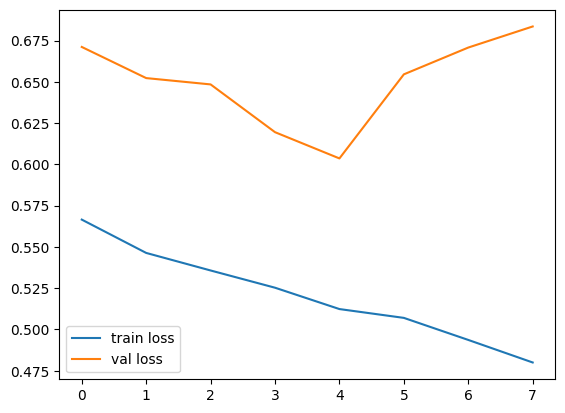

In [ ]:
plt.plot(history.history['loss'], label='train loss')
plt.plot(history.history['val_loss'], label='val loss')
plt.legend(); plt.show()


In [ ]:
import numpy as np

# Validation data se predictions
y_pred_prob = model.predict(val_data)
y_pred = (y_pred_prob > 0.5).astype(int)   # threshold 0.5
y_true = val_data.classes


222/222 ━━━━━━━━━━━━━━━━━━━━ 121s 541ms/step


In [ ]:
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score

cm = confusion_matrix(y_true, y_pred)
precision = precision_score(y_true, y_pred)
recall = recall_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)

print("Confusion Matrix:\n", cm)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)


Confusion Matrix:
 [[1501 2267]
 [1290 2034]]
Precision: 0.4729132759823297
Recall: 0.6119133574007221
F1 Score: 0.5335081967213114


In [ ]:
import cv2
import numpy as np

img = cv2.imread('/content/drive/MyDrive/project Ml/Axial CT Imaging Dataset for AI-Powered Kidney Stone Detection A Resource for Deep Learning Research/Kindy Stone Dataset/Original Dataset/Non-Stone/100.jpg')
img = cv2.resize(img, (150,150))
img = img / 255.0
img = np.expand_dims(img, axis=0)

prediction = model.predict(img)
if prediction[0][0] > 0.5:
    print("Kidney Stone Detected ⚠️")
else:
    print("Normal Kidney ✅")


NameError: name 'model' is not defined

In [ ]:
from tensorflow.keras.models import load_model

In [ ]:
model.save("E:/programing/models/kidney_stone_detection_model.h5")

In [ ]:
model.save("E:/programing/models/my_model2.keras")
print("Model saved successfully!")

Model saved successfully!
